## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import os 
import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/') # change to your ultrasonicTesting directory
from tqdm import tqdm

import numpy as np
import pandas as pd
import pywt


from matplotlib import pyplot as plt
from scipy.signal import butter, sosfiltfilt

import tomography as tm
import pickleJar as pj

In [3]:
# # w front wall
# sqlite_file = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Group/Data/Ultrasound/General Motors/Prismatic Data/08172026_jellyroll_back_pulseecho_150_32mm_1mm_0_02_voltrange.sqlite3'

# wo front wall
sqlite_file = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Group/Data/Ultrasound/General Motors/Prismatic Data/08172026_jellyroll_front_pulseecho_150_32mm_1mm_0_02_voltrange_changedtimetime1786999468.sqlite3'

dir, filename = os.path.split(sqlite_file)
pj.sqliteToPickle(sqlite_file)

pickle_file = sqlite_file.replace('.sqlite3', '.pickle')
pickle_data = pj.loadPickle(pickle_file)

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Group/Data/Ultrasound/General Motors/Prismatic Data/08172026_jellyroll_front_pulseecho_150_32mm_1mm_0_02_voltrange_changedtimetime1786999468.pickle already exists. Conversion aborted.


In [4]:
# convert to pandas datafram for easier access
waveform_df = pd.DataFrame({k:v for k,v in pickle_data.items() if isinstance(k, int)}).transpose() 

## get info about sampling freq, etc

In [5]:
dt = (pickle_data[0]['time'][1] - pickle_data[0]['time'][0]) * 1e-9
omega_scaled = pickle_data['parameters']['transducerFrequency'] * 1e6 * dt
samples = pickle_data['parameters']['samples']
waves = pickle_data['parameters']['waves']
fs = 1/dt

# butterworth filter
# sos = butter(3, fs/250, btype = 'highpass', analog = False, fs = fs, output = 'sos')
# sos = butter(3, fs/10, btype = 'lowpass', analog = False, fs = fs, output = 'sos')
# you can change the wn = [high, low] passband if you know feature size
sos = butter(3, [fs/250,fs/5], btype = 'bandpass', analog = False, fs = fs, output = 'sos') 
refGain = pickle_data['parameters']['gainForward'] / 10 # dont need unless gain is changing

def ungain_filter(x):
    '''function to ungain and filter a signal'''
    # change signal to pre-amplification voltage
    # x_ungained = pj.correctVoltageByGain(x, refGain) # don't need unless gain is changing
    # apply butterworth filter forward and reverse to pre-amplified signal
    x_filtered = sosfiltfilt(sos, x)
    return x_filtered

## preprocess and calculate transforms

In [6]:
# preprocess 
waveform_df['voltage_preprocessed'] = waveform_df['voltage'].apply(ungain_filter)

In [7]:
# i = 3000

# plt.plot(waveform_df['time'][i], waveform_df['voltage_preprocessed'][i], label = 'bandpass filtering')
# plt.plot(waveform_df['time'][i], waveform_df['voltage'][i]-waveform_df['voltage'][i].min(), label = 'no bandpass filtering (min subtraction)')
# plt.legend()

In [8]:
# pywt's complex Morlet is parameterized as 'cmorB-C'
# B = bandwidth parameter, C = center frequency (normalized, dimensionless)
# For matching a known pulse center frequency, C=1.0 with B~1.0-2.0 works well;
# increase B for better frequency resolution (worse time resolution)
# TODO: we need to figure out what the pulse width of compact puler is. it is fixed by transducer frequency i think

wavelet = 'cmor0.5-1.0' # we can make B a little smaller since we dont care ab frequency as much

freqs_of_interest = np.linspace(100e3, 4e6, 100)   # 100kHz-4 MHz. You can change the nmber of freq calculations to do. Takes a lot of memory tho
central_freq = pywt.central_frequency(wavelet)      # normalized center freq of the wavelet
scales = central_freq * fs / freqs_of_interest      # scale = f_c * fs / f_target
freqs_hz = pywt.scale2frequency(wavelet, scales) * fs

In [9]:
# gets wavelet transforms. slow af and takes a lot of memory
# maybe u wanna save the new dataframe as a csv or pickle and not run this every time

def get_cwt(row):
    coeffs, _ = pywt.cwt(row['voltage_preprocessed'], scales, wavelet, sampling_period=dt)
    return coeffs

tqdm.pandas()
waveform_df['morlet_cwt'] = waveform_df.progress_apply(get_cwt, axis=1)

100%|██████████| 4983/4983 [02:06<00:00, 39.32it/s]


In [10]:
# get_magnitudes of the wavelet transforms
def cwt_magnitude(row):
    return np.abs(row['morlet_cwt'])

tqdm.pandas()
waveform_df['morlet_cwt_magnitude'] = waveform_df.progress_apply(cwt_magnitude, axis=1)

100%|██████████| 4983/4983 [00:47<00:00, 105.52it/s]


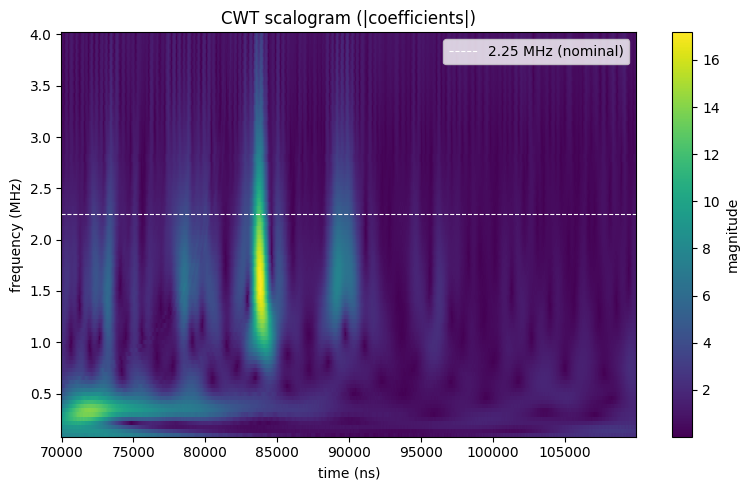

In [ ]:
# visualize cwt. streakiness is caused by the spacing at the frequency being larger

i=3000

plt.figure(figsize=(8, 5))
plt.pcolormesh(waveform_df.loc[i]['time'], freqs_hz / 1e6, waveform_df.loc[i]['morlet_cwt_magnitude'], 
               shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('frequency (MHz)')
plt.title('CWT scalogram (|coefficients|)')
plt.colorbar(label='magnitude')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
from scipy.signal import find_peaks

# find the CWT coefficients within 5% of 2.25 MHz
freq_center = 2.25e6
band_frac = 0.05
band_mask = (freqs_hz >= freq_center * (1 - band_frac)) & (freqs_hz <= freq_center * (1 + band_frac))
freq_window = freqs_hz[band_mask]

def get_badpass_profile(row):
    '''get peak location of max value in the frequency band of interest'''
    return np.max(row['morlet_cwt_magnitude'][band_mask], 
                         axis=0)
    
tqdm.pandas()
waveform_df['morlet_bandpass_profile'] = waveform_df.progress_apply(get_badpass_profile, axis=1)


100%|██████████| 4983/4983 [00:00<00:00, 19592.59it/s]


In [17]:
def get_peak_times(row):
    peaks, properties = find_peaks(
        row['morlet_bandpass_profile'],
        prominence=0.1 * row['morlet_bandpass_profile'].max()
    )

    return peaks

tqdm.pandas()
waveform_df['morlet_cwt_peak_inds'] = waveform_df.progress_apply(get_peak_times, axis=1)

100%|██████████| 4983/4983 [00:00<00:00, 11931.41it/s]


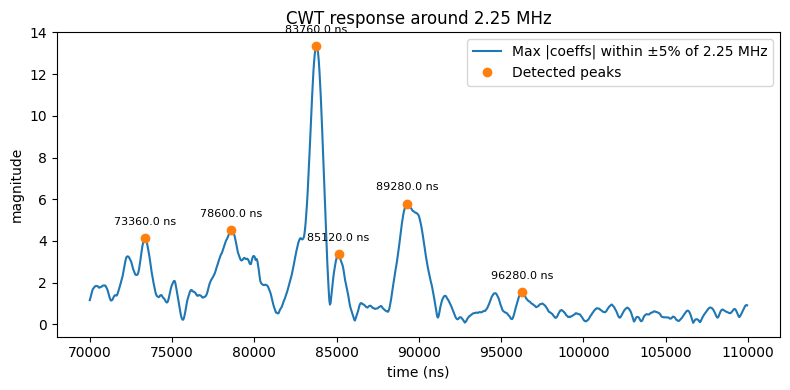

In [18]:
# visualize cwt bandpass profile and peaks
i=3000

peak_inds = waveform_df.loc[i]['morlet_cwt_peak_inds']

plt.figure(figsize=(8, 4))
plt.plot(waveform_df.loc[i]['time'], waveform_df.loc[i]['morlet_bandpass_profile'], 
         label=f'Max |coeffs| within ±{band_frac * 100:.0f}% of {freq_center / 1e6:.2f} MHz')

plt.plot(waveform_df.loc[i]['time'][peak_inds], 
         waveform_df.loc[i]['morlet_bandpass_profile'][peak_inds], 
         'o', label='Detected peaks')

for x, y in zip(waveform_df.loc[i]['time'][peak_inds], waveform_df.loc[i]['morlet_bandpass_profile'][peak_inds]):
    plt.annotate(
        f'{x:.1f} ns',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

plt.xlabel('time (ns)')
plt.ylabel('magnitude')
plt.title('CWT response around 2.25 MHz')
plt.legend()
plt.tight_layout()
plt.show()

I'm still figuring out exactly what the phase and group delay mean in a cwt so maybe you don't have to include this...

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_91937/3136621430.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


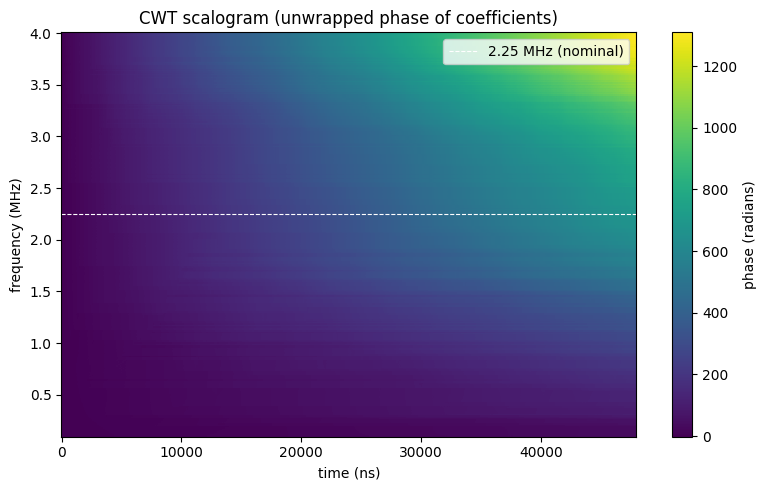

In [ ]:
phase = np.unwrap(np.angle(waveform_df.loc[i]['morlet_cwt']))

plt.figure(figsize=(8, 5))
plt.pcolormesh(t, freqs_hz / 1e6, phase, shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('frequency (MHz)')
plt.title('CWT scalogram (unwrapped phase of coefficients)')
plt.colorbar(label='phase (radians)')
plt.legend()
plt.tight_layout()
plt.show()

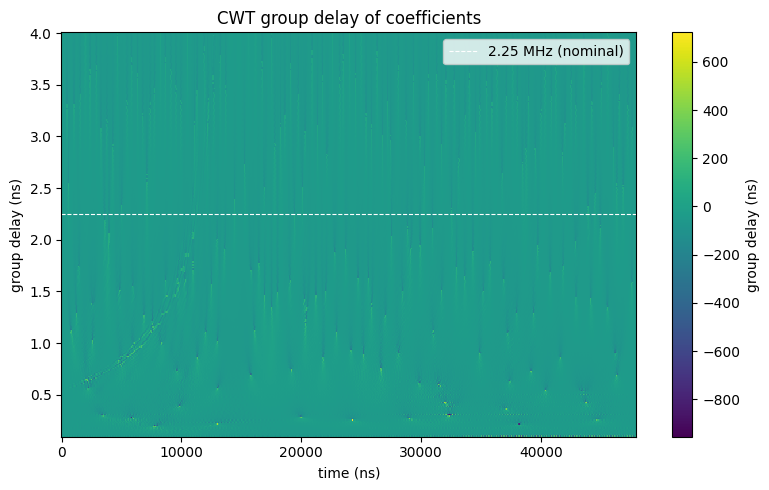

In [ ]:
group_delay = -np.gradient(phase, axis=1) / (2 * np.pi * freqs_hz[:, np.newaxis]) * 1e9  # convert to ns

plt.figure(figsize=(8, 5))
plt.pcolormesh(t, freqs_hz / 1e6, group_delay, shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('group delay (ns)')
plt.title('CWT group delay of coefficients')
plt.colorbar(label='group delay (ns)')
plt.legend()
plt.tight_layout()
plt.show()